In [41]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense,Input
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


In [42]:
print("Fine Tuning the ANN Model ")


Fine Tuning the ANN Model 


In [43]:
print("Uploading the Data")
data=pd.read_csv("data.csv")
df=pd.DataFrame(data)
print(df.head())

Uploading the Data
         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  texture_worst  perimeter_worst  are

In [44]:
print("Data Shape : " , df.shape)
print("Details of the dataset :\n", df.describe())


Data Shape :  (569, 33)
Details of the dataset :
                  id  radius_mean  texture_mean  perimeter_mean    area_mean  \
count  5.690000e+02   569.000000    569.000000      569.000000   569.000000   
mean   3.037183e+07    14.127292     19.289649       91.969033   654.889104   
std    1.250206e+08     3.524049      4.301036       24.298981   351.914129   
min    8.670000e+03     6.981000      9.710000       43.790000   143.500000   
25%    8.692180e+05    11.700000     16.170000       75.170000   420.300000   
50%    9.060240e+05    13.370000     18.840000       86.240000   551.100000   
75%    8.813129e+06    15.780000     21.800000      104.100000   782.700000   
max    9.113205e+08    28.110000     39.280000      188.500000  2501.000000   

       smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
count       569.000000        569.000000      569.000000           569.000000   
mean          0.096360          0.104341        0.088799             0.04891

In [45]:
print("Information of the columns : " , df.info())

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             569 non-null

In [46]:
print("Making the data clean")
print(df.isnull().sum())
print("No Null Values")

Making the data clean
id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension

In [47]:
print("Searching Missing Values and Handling")
print(df.isna().sum())
print()
print(df.dropna().sum())
print("All Set")
print(df["diagnosis"].value_counts())

Searching Missing Values and Handling
id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
f

In [48]:
print("Time to preprocess the dataset ")
print("First Remove the columns which are unimportant to identify the disease")
df=df.drop(columns=["id","Unnamed: 32"])
print(df.head())

Time to preprocess the dataset 
First Remove the columns which are unimportant to identify the disease
  diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0         M        17.99         10.38          122.80     1001.0   
1         M        20.57         17.77          132.90     1326.0   
2         M        19.69         21.25          130.00     1203.0   
3         M        11.42         20.38           77.58      386.1   
4         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   symmetry_mean  .

In [59]:
print("Selecting the data and target samples")
X=df.drop("diagnosis",axis=1)
y=df["diagnosis"]
print("X Shape : " ,X.shape)
print("y Shape : ", y.shape)
print("X Columns : \n" , X.columns)
print("y Values : \n",y.value_counts())

Selecting the data and target samples
X Shape :  (569, 30)
y Shape :  (569,)
X Columns : 
 Index(['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean',
       'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='str')
y Values : 
 diagnosis
B    357
M    212
Name: count, dtype: int64


In [61]:
print("B -> Benign (Non-Cancerous) -> 0")
print("M -> Malignant (Cancerous) -> 1")
y=y.map({
    'B':0,
    'M':1
})
print(y)

B -> Benign (Non-Cancerous) -> 0
M -> Malignant (Cancerous) -> 1
0      1
1      1
2      1
3      1
4      1
      ..
564    1
565    1
566    1
567    1
568    0
Name: diagnosis, Length: 569, dtype: int64


In [63]:
print("Splitting the dataset into training and testing")
X_train,X_test,y_train,y_test=train_test_split(X,y,
                                               test_size=0.4,
                                               random_state=42,
                                               stratify=y
                                              )
print("X_train Shape : " ,X_train.shape)
print("X_test Shape : " ,X_test.shape)
print("y_train Shape : " ,y_train.shape)
print("y_test Shape : " ,y_test.shape)

Splitting the dataset into training and testing
X_train Shape :  (341, 30)
X_test Shape :  (228, 30)
y_train Shape :  (341,)
y_test Shape :  (228,)


In [67]:
print("Feature Scaling")
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)
print("X_train_scaled Shape : " ,X_train_scaled.shape)
print("X_train_scaled :\n" ,X_train_scaled[:4])
print("X_test_scaled Shape : " ,X_test_scaled.shape)
print("X_test_scaled : \n" ,X_test_scaled[:4])

Feature Scaling
X_train_scaled Shape :  (341, 30)
X_train_scaled :
 [[ 0.19284626  1.00157434  0.23722908  0.04666421  1.47659984  0.87966091
   0.51319118  1.10897093  0.50004389  0.54950568 -0.18268366  0.0725701
  -0.21002971 -0.11610026 -0.0829288  -0.10149223 -0.26049069  0.02410679
  -0.18044649 -0.19289527  0.22774552  1.19111976  0.23935283  0.09524387
   1.41094246  0.61449263  0.17874221  0.72817434  0.65454821  0.31178956]
 [-1.2740721  -0.25143863 -1.26371573 -1.05531883 -0.44323994 -0.74166232
  -0.7150092  -0.85930545  1.53584681  0.2166667  -0.11204219  0.19326037
  -0.15163484 -0.39839218  0.18768096 -0.28138648 -0.14330268 -0.28090141
  -0.11150781  0.06489744 -1.08051062 -0.07175231 -1.10157997 -0.89462085
  -0.34932074 -0.60093271 -0.66616592 -0.73465124  0.42619138  0.10016401]
 [ 0.1526803  -0.62849208  0.10389536  0.03998024 -0.65432543 -0.65804977
  -0.43152003 -0.52484252 -1.47706764 -1.24451019 -0.6700743  -0.40844186
  -0.69043792 -0.46044676 -1.1572292  -0.61

In [71]:
print("Creating Validation Sets")
X_train,X_val,y_train,y_val=train_test_split(
    X_train,
    y_train,
    test_size=0.4,
    random_state=42,
    stratify=y_train)
print("X_train Shape:", X_train.shape)
print("X_val Shape:", X_val.shape)
print("X_test Shape:", X_test.shape)

print("y_train Shape:", y_train.shape)
print("y_val Shape:", y_val.shape)
print("y_test Shape:", y_test.shape)

print("Scaling the validation values")
X_train_scaled=scaler.fit_transform(X_train)
X_val_scaled=scaler.transform(X_val)
X_test_scaled=scaler.transform(X_test)

Creating Validation Sets
X_train Shape: (122, 30)
X_val Shape: (82, 30)
X_test Shape: (228, 30)
y_train Shape: (122,)
y_val Shape: (82,)
y_test Shape: (228,)
Scaling the validation values


In [87]:
from tensorflow.keras.layers import Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l1, l2
print("ANN TUNED MODEL")
model=Sequential()
#Model Setting
#Input Layer
model.add(Input(shape=(30,))) 
#Hidden Layer 1
model.add(Dense(32,activation='relu',kernel_regularizer=l1(0.001)))
model.add(Dropout(0.2))          
#Hidden Layer 2
model.add(Dense(16,activation='relu',kernel_regularizer=l2(0.001))) 
#Hiden Layer 3 
model.add(Dense(8,activation='relu')) 
#Output Layer
model.add(Dense(1,activation='sigmoid'))
#Model Compiling
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])
#Model Training
history=model.fit(
    X_train_scaled,
    y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_val_scaled,y_val))
y_pred=model.predict(X_test_scaled)
y_pred_class=(y_pred>=0.5).astype(int)
print("Evaluating the Model:\n---------------------")
loss,accuracy=model.evaluate(X_test_scaled,y_test)
print("Test Loss : ",loss)
print("Test Accuracy : " , accuracy)
print("Recall : " ,recall_score(y_test,y_pred_class))
print("Precision : " ,precision_score(y_test,y_pred_class))


ANN TUNED MODEL
Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step - accuracy: 0.6311 - loss: 0.8831 - val_accuracy: 0.6220 - val_loss: 0.7950
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.6311 - loss: 0.8141 - val_accuracy: 0.6220 - val_loss: 0.7522
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.6311 - loss: 0.7771 - val_accuracy: 0.6220 - val_loss: 0.7166
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.6311 - loss: 0.7336 - val_accuracy: 0.6220 - val_loss: 0.6860
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.6311 - loss: 0.7242 - val_accuracy: 0.6220 - val_loss: 0.6626
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.6311 - loss: 0.6902 - val_accuracy: 0.6220 - val_loss: 0.6440
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6393 - loss: 0.6767 - val_accuracy: 0.6220 - val_loss: 0.6291
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6393 - loss: 0.6159 - val_accuracy: 0.

Confusion Matrix


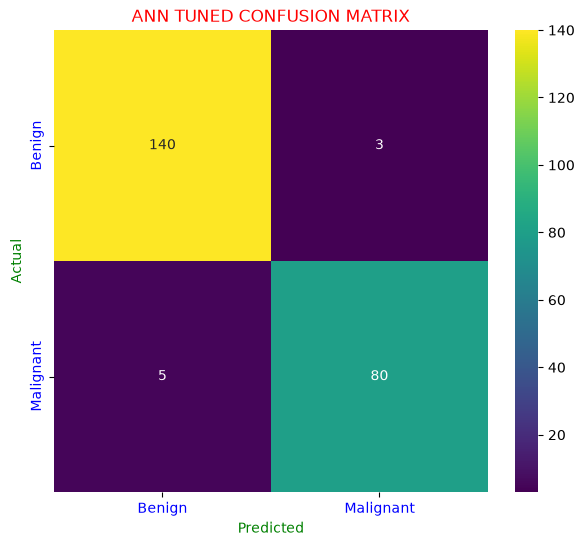

In [89]:
print("Confusion Matrix")
cm=confusion_matrix(y_test,y_pred_class)
plt.figure(figsize=(7,6))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='viridis',
            xticklabels=['Benign','Malignant'],
            yticklabels=['Benign','Malignant'])
plt.xlabel("Predicted",color='green')
plt.ylabel("Actual",color='green')
plt.xticks(color='blue')
plt.yticks(color='blue')
plt.title('ANN TUNED CONFUSION MATRIX',color="red")
plt.show()
        

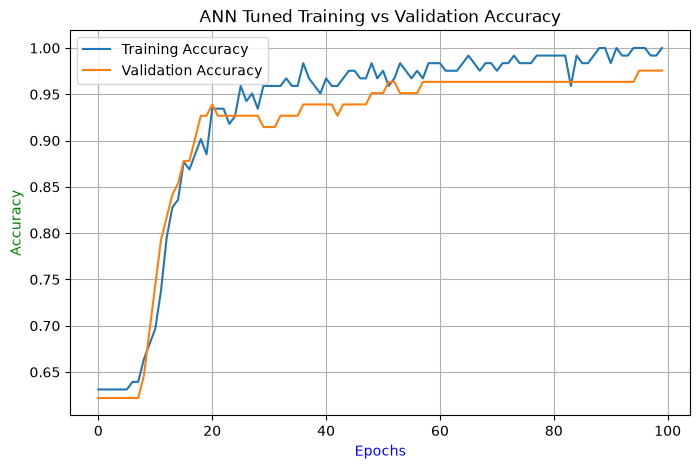

In [95]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'],label='Training Accuracy')
plt.plot(history.history['val_accuracy'],label='Validation Accuracy')

plt.xlabel('Epochs',color="blue")
plt.ylabel('Accuracy',color="green")
plt.title("ANN Tuned Training vs Validation Accuracy")

plt.legend()
plt.grid()
plt.show()